In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
sales_data = pd.read_csv('advertising.csv')

sales_data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
sales_data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [5]:
sales_data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

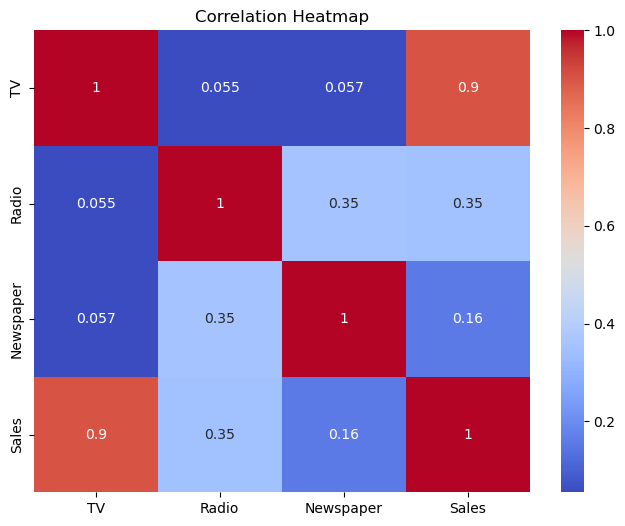

In [6]:
plt.figure(figsize=(8,6))

sns.heatmap(
    sales_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

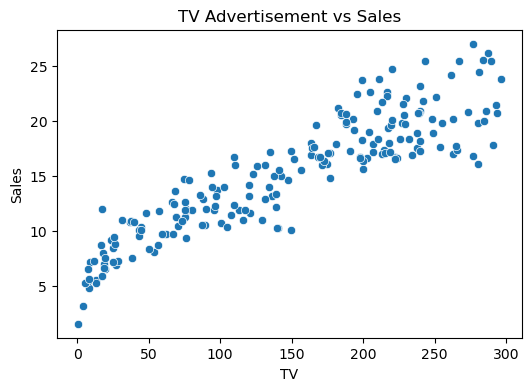

In [7]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='TV',
    y='Sales',
    data=sales_data
)

plt.title('TV Advertisement vs Sales')

plt.show()

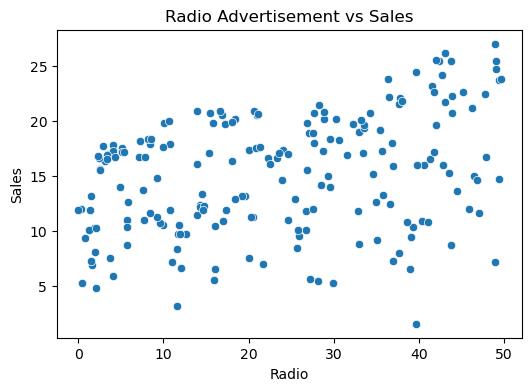

In [8]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='Radio',
    y='Sales',
    data=sales_data
)

plt.title('Radio Advertisement vs Sales')

plt.show()

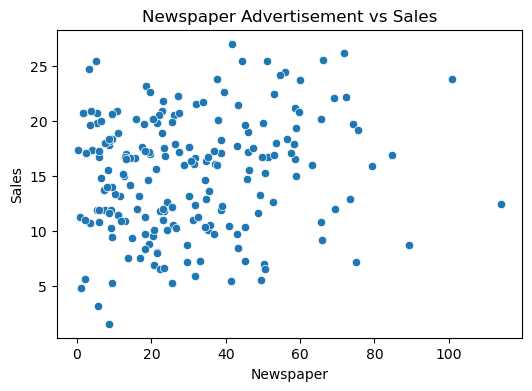

In [9]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='Newspaper',
    y='Sales',
    data=sales_data
)

plt.title('Newspaper Advertisement vs Sales')

plt.show()

In [10]:
X = sales_data[['TV', 'Radio', 'Newspaper']]

y = sales_data['Sales']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
lr_predictions = lr_model.predict(X_test)

In [14]:
print("Mean Absolute Error:",
      mean_absolute_error(y_test, lr_predictions))

print("Mean Squared Error:",
      mean_squared_error(y_test, lr_predictions))

print("R2 Score:",
      r2_score(y_test, lr_predictions))

Mean Absolute Error: 1.274826210954934
Mean Squared Error: 2.907756910271092
R2 Score: 0.9059011844150826


In [15]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
rf_predictions = rf_model.predict(X_test)

In [17]:
print("Mean Absolute Error:",
      mean_absolute_error(y_test, rf_predictions))

print("Mean Squared Error:",
      mean_squared_error(y_test, rf_predictions))

print("R2 Score:",
      r2_score(y_test, rf_predictions))

Mean Absolute Error: 0.9140749999999972
Mean Squared Error: 1.3991268375000003
R2 Score: 0.9547224261434059


In [18]:
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': rf_predictions
})

comparison.head()

,Actual Sales,Predicted Sales
0,16.9,17.4155
1,22.4,22.4250
2,21.4,19.8375
3,7.3,6.7945
4,24.7,22.9620


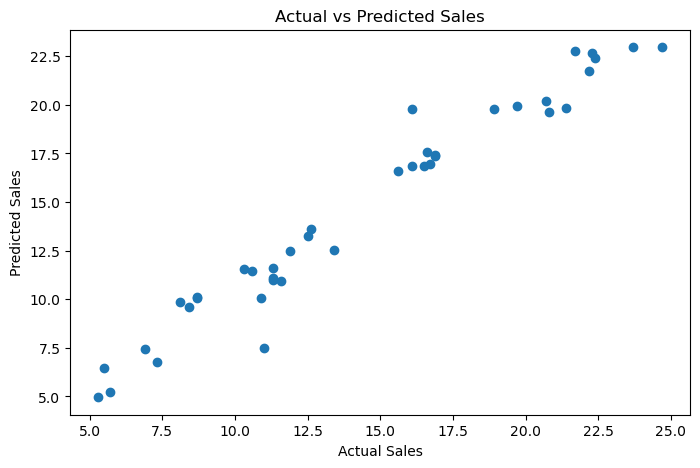

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    rf_predictions
)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.title('Actual vs Predicted Sales')

plt.show()

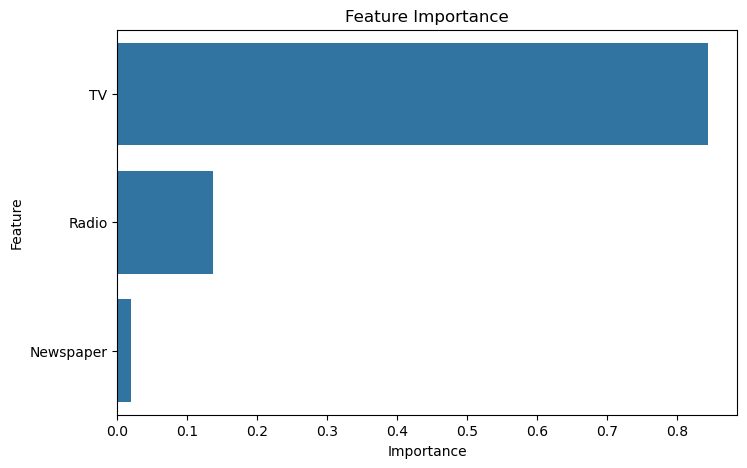

In [20]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

In [21]:
sample_data = pd.DataFrame({
    'TV': [230],
    'Radio': [37],
    'Newspaper': [69]
})

prediction = rf_model.predict(sample_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 21.810999999999986
